### Welcome! This notebook will help you get started with geospatial analysis using geopandas.

In [1]:
# install geopandas if you haven't already
%pip install geopandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
# import dependencies
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt


Let's begin with reading and viewing the first dataset, the USDA Food Deserts shapefile. These GIS files contain data and metadata regarding all food desert census tracts in the state of Georgia. 

Geopandas uses very similar syntax to pandas for most functions, though there are some differences to be aware of. For example, geopandas exclusively uses the function read_file() rather than stating the file type.

In [3]:
food_deserts = gpd.read_file("InvestAtlanta_export/lila_halfmi_census.shp")
food_deserts.head()

,CnssTrc,State,County,LILAT_1A1,LILAT_A,LILAT_1A2,LILAT_V,PvrtyRt,MdnFmlI,LAhlf10,...,tract,STATEFP,COUNTYF,TRACTCE,BLOCKCE,BLOCKID,PARTFLG,HOUSING,POP10,geometry
0,13121000600,Georgia,Fulton County,0.0,1.0,0.0,1.0,43.86073,96850,1.0,...,000600,13,121,000600,1060,131210006001060,N,329,342,"POLYGON ((-84.40747 33.78225, -84.40748 33.781..."
1,13121000600,Georgia,Fulton County,0.0,1.0,0.0,1.0,43.86073,96850,1.0,...,000600,13,121,000600,1054,131210006001054,N,7,20,"POLYGON ((-84.40419 33.78154, -84.4043 33.7817..."
2,13121000600,Georgia,Fulton County,0.0,1.0,0.0,1.0,43.86073,96850,1.0,...,000600,13,121,000600,1053,131210006001053,N,23,26,"POLYGON ((-84.40263 33.78153, -84.40273 33.781..."
3,13121000600,Georgia,Fulton County,0.0,1.0,0.0,1.0,43.86073,96850,1.0,...,000600,13,121,000600,1074,131210006001074,N,0,0,"POLYGON ((-84.41343 33.78159, -84.41341 33.781..."
4,13121000600,Georgia,Fulton County,0.0,1.0,0.0,1.0,43.86073,96850,1.0,...,000600,13,121,000600,1070,131210006001070,N,0,0,"POLYGON ((-84.41069 33.78062, -84.41243 33.780..."


As you can see above, geopandas "GeoDataFrames" can still use many standard functions of regular pandas DataFrames, such as .head(), .shape, .summarise(), etc.

<Axes: >

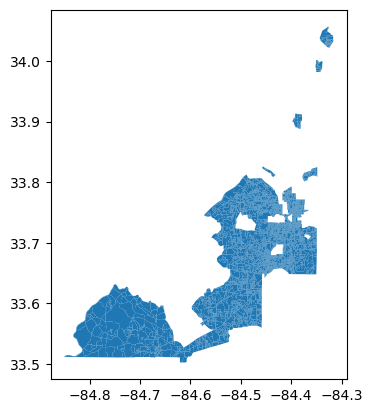

In [4]:
food_deserts.plot()

One important aspect of working with geospatial data is understanding which coordinate reference system (CRS) each dataset uses. This is similar to working with lengths in miles or kilometers or temperatures in Celsius or Fahrenheit; if you try to compare two datasets that were created using different measurement systems, the results will be nonsensical.

In [5]:
food_deserts.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

This CRS epsg:4326 is the most common CRS in all of GIS. This is named the "World Geodetic Standard" (WGS) because it is the global standard system to use. This coordinate reference system uses degrees latitude and longitude, though there is also a metric counterpart to the same world standard that can be used when more precise mathematical calculations are needed, epsg:3857

Now we will load another dataset, this time from excel. Because excel cannot store GIS metadata in the same way as shapefiles, we will first load the dataset as a regular DataFrame, then convert it to a GeoDataFrame.

In [6]:
biz_data = pd.read_excel("InvestAtlanta_export/Atlanta_Business_License_Records_2025.xlsx")
biz_data.head()

,license_number,company_name,company_dba,license_classification,issued_date,naics_code,naics_name,predirection,address_line1,address_line2,...,city,state,postal_code,address_concat,address_api,longitude,latitude,disinvested_neighborhood,council_district,npu
0,GBL-0121-00257,H & H Interiors LLC,NaN,Other Services except Public Administration,2025-01-07 13:21:16.143,541410.0,Interior Design Services,NE,2652 Forrest,NaN,...,Atlanta,GA,NaN,2652 Forrest nan WAY Atlanta GA nan,"2652 Forrest Way NE, Atlanta, Georgia, 30305",-84.379893,33.827640,False,7,B
1,GBL-0121-00258,One Lion Studios LLC,NaN,Other Services except Public Administration,2025-02-16 18:39:21.153,541840.0,Media Representatives,NaN,3343 Peachtree Rd NE,NaN,...,Atlanta,GA,30326,3343 Peachtree Rd NE nan nan Atlanta GA 30326,"3343 Peachtree Rd NE, Atlanta, Georgia, 30326",-84.367109,33.846760,False,7,B
2,GBL-0121-00272,Destingkt Designs LLC,NaN,Other Services except Public Administration,2025-03-04 23:04:53.980,541410.0,Interior Design Services,NaN,931,PONCE DE LEON,...,Atlanta,GA,NaN,931 PONCE DE LEON AVE Atlanta GA nan,"931 Ponce de Leon Ave NE, Atlanta, Georgia, 30306",-84.356939,33.773524,False,2,N
3,GBL-0121-00274,Mac Cigars LLC,J's Cigars,Retail Trade,2025-02-25 23:09:11.497,453991.0,Tobacco Stores,NaN,2072,Defoors Ferry,...,Atlanta,GA,30318,2072 Defoors Ferry RD Atlanta GA 30318,"2072 Defoors Ferry Rd NW, Atlanta, Georgia, 30318",-84.426318,33.812071,False,9,D
4,GBL-0121-00283,Essence of She Day Spa Salon,NaN,Other Services except Public Administration,2025-01-09 19:04:30.857,812112.0,Beauty Salons,NaN,144,MORELAND,...,ATLANTA,GA,30307,144 MORELAND AVE ATLANTA GA 30307,"144 Moreland Ave NE, Atlanta, Georgia, 30307",-84.349501,33.756604,False,5,N


As you can see, the latitude and longitude values are stored in columns for every business address in the dataset. This enables you to create coordinates from those columns, using the geopandas function points_from_xy()

In [7]:
biz_geo = gpd.GeoDataFrame(biz_data, geometry = gpd.points_from_xy(biz_data['latitude'], biz_data['longitude']), crs = 4326)

In this one line, three important things are happening:
1. We coerce the dataframe to a geodataframe using geopandas
2. The latitude and longitude columns are converted to coordinate points using points_from_xy()
3. Because there are no metadata files geopandas can use to determine the CRS, you must manually state which CRS was used in these coordinates. In this case, we know that the datset was created using a geocoding API that returns coordinates in epsg:4326, which is extremely common. If you ever don't know which CRS was used for a dataset you want to work with, there are ways to troubleshoot, but it's best to download geospatial data as shapefiles or geojson whenever possible to avoid the issue.

### Week 2 homework

Now it's your turn! Can you plot the business license data? What can you learn about the dataset from the map that isn't clear when otherwise? What surprises you about the dataset, if anything?

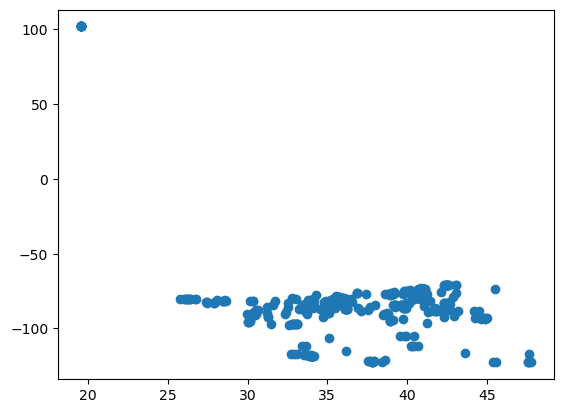

In [8]:
plt.plot(biz_data['latitude'], biz_data['longitude'], 'o')

In [9]:
import pandas as pd
import plotly.express as px

# Load data
df = pd.read_csv("/Users/zachschneider/Documents/GitHub/AI Data Lab Spring 25/Atlanta_Business_License_Records_2025.xlsx - Filtered_Fresh_Food.csv")

# Drop missing coordinates
df = df.dropna(subset=["latitude", "longitude"])

# Create interactive map
fig = px.scatter_mapbox(
    df,
    lat="latitude",
    lon="longitude",
    zoom=10,
    height=800,
    title="Atlanta Business Licenses (2025)"
)

fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0})

fig.show()


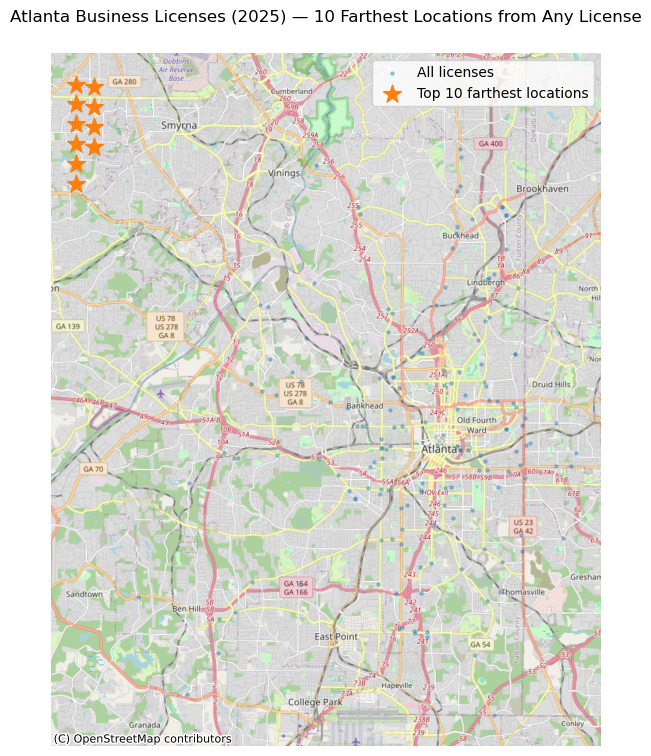

 star_latitude  star_longitude  distance_to_nearest_license_km
     33.900000      -84.564369                       11.210177
     33.892083      -84.564369                       10.963622
     33.884166      -84.564369                       10.783503
     33.876249      -84.564369                       10.673182
     33.898869      -84.555688                       10.411160
     33.868332      -84.564369                       10.304100
     33.890952      -84.555688                       10.156038
     33.883035      -84.555688                        9.972357
     33.875118      -84.555688                        9.864112
     33.860415      -84.564369                        9.793540


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- optional basemap deps ---
USE_BASEMAP = True
try:
    import geopandas as gpd
    import contextily as ctx
except Exception:
    USE_BASEMAP = False

# -----------------------------
# 1) Load & clean
# -----------------------------
df = pd.read_csv("Atlanta_Business_License_Records_2025.xlsx - Filtered_Fresh_Food.csv")

df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")
df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")
df = df.dropna(subset=["latitude", "longitude"]).copy()

# If your file includes outliers far away, you can optionally trim:
# df = df[(df["latitude"].between(33.5, 34.1)) & (df["longitude"].between(-84.8, -84.0))]

# -----------------------------
# 2) Define an "Atlanta area" search box
#    (use data bounds + padding, clamped to a reasonable Atlanta bbox)
# -----------------------------
lat_min, lat_max = df["latitude"].min(), df["latitude"].max()
lon_min, lon_max = df["longitude"].min(), df["longitude"].max()

pad_lat = 0.03
pad_lon = 0.03

# Clamp to a reasonable Atlanta metro-ish box so a few stray points don't explode the map
ATL_LAT_MIN, ATL_LAT_MAX = 33.60, 33.90
ATL_LON_MIN, ATL_LON_MAX = -84.60, -84.25

lat0 = max(lat_min - pad_lat, ATL_LAT_MIN)
lat1 = min(lat_max + pad_lat, ATL_LAT_MAX)
lon0 = max(lon_min - pad_lon, ATL_LON_MIN)
lon1 = min(lon_max + pad_lon, ATL_LON_MAX)

# -----------------------------
# 3) Create candidate locations (grid) and find farthest-from-nearest-license points
# -----------------------------
# Grid resolution: increase for better accuracy (but slower)
N = 250  # 250x250 = 62,500 candidates
lats = np.linspace(lat0, lat1, N)
lons = np.linspace(lon0, lon1, N)
grid_lon, grid_lat = np.meshgrid(lons, lats)
candidates = np.column_stack([grid_lat.ravel(), grid_lon.ravel()])  # (lat, lon)

# Use BallTree (fast) if available
try:
    from sklearn.neighbors import BallTree

    # BallTree with haversine expects radians, and points in (lat, lon)
    license_pts = np.radians(df[["latitude", "longitude"]].to_numpy())
    cand_pts = np.radians(candidates)

    tree = BallTree(license_pts, metric="haversine")
    # dist is radians on Earth's sphere -> convert to km
    dist_rad, _ = tree.query(cand_pts, k=1)
    dist_km = dist_rad[:, 0] * 6371.0088
except Exception:
    # Fallback: chunked haversine (slower, but no sklearn needed)
    def haversine_km(lat1, lon1, lat2, lon2):
        R = 6371.0088
        lat1 = np.radians(lat1)
        lon1 = np.radians(lon1)
        lat2 = np.radians(lat2)
        lon2 = np.radians(lon2)
        dlat = lat2 - lat1
        dlon = lon2 - lon1
        a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
        return 2 * R * np.arcsin(np.sqrt(a))

    license_lat = df["latitude"].to_numpy()
    license_lon = df["longitude"].to_numpy()

    dist_km = np.empty(len(candidates))
    chunk = 2000
    for i in range(0, len(candidates), chunk):
        sub = candidates[i:i+chunk]
        # compute min distance to any license point
        # (broadcast: each candidate vs all points)
        mins = []
        for lat, lon in sub:
            d = haversine_km(lat, lon, license_lat, license_lon)
            mins.append(d.min())
        dist_km[i:i+chunk] = np.array(mins)

# Greedy pick top 10 farthest candidates, enforcing spacing so stars don’t stack
order = np.argsort(-dist_km)  # descending by distance
picked = []
min_sep_km = 0.8  # prevents stars bunching; adjust as needed

def approx_km_between(a, b):
    # quick approx for spacing: 1 deg lat ~ 111km, 1 deg lon ~ 111km*cos(lat)
    lat1, lon1 = a
    lat2, lon2 = b
    dlat_km = abs(lat1 - lat2) * 111.0
    dlon_km = abs(lon1 - lon2) * 111.0 * np.cos(np.radians((lat1 + lat2) / 2))
    return np.sqrt(dlat_km**2 + dlon_km**2)

for idx in order:
    pt = candidates[idx]
    if len(picked) == 0:
        picked.append((pt[0], pt[1], dist_km[idx]))
    else:
        ok = all(approx_km_between(pt, (p[0], p[1])) >= min_sep_km for p in picked)
        if ok:
            picked.append((pt[0], pt[1], dist_km[idx]))
    if len(picked) >= 10:
        break

stars_lat = np.array([p[0] for p in picked])
stars_lon = np.array([p[1] for p in picked])
stars_km  = np.array([p[2] for p in picked])

# -----------------------------
# 4) Plot: licenses + stars + basemap background
# -----------------------------
if USE_BASEMAP:
    # Plot in Web Mercator so basemap tiles align
    gdf_pts = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
        crs="EPSG:4326"
    ).to_crs(epsg=3857)

    gdf_star = gpd.GeoDataFrame(
        pd.DataFrame({"dist_km": stars_km}),
        geometry=gpd.points_from_xy(stars_lon, stars_lat),
        crs="EPSG:4326"
    ).to_crs(epsg=3857)

    fig, ax = plt.subplots(figsize=(9, 9))

    gdf_pts.plot(ax=ax, markersize=5, alpha=0.35, label="All licenses")
    gdf_star.plot(ax=ax, markersize=180, marker="*", label="Top 10 farthest locations")

    # Add basemap
    ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

    ax.set_axis_off()
    ax.set_title("Atlanta Business Licenses (2025) — 10 Farthest Locations from Any License", pad=12)
    ax.legend()
    plt.show()

else:
    # No basemap available: plain scatter like your first graph, but correct stars
    fig, ax = plt.subplots(figsize=(9, 9))

    ax.scatter(df["longitude"], df["latitude"], s=5, alpha=0.35, label="All licenses")
    ax.scatter(stars_lon, stars_lat, s=180, marker="*", label="Top 10 farthest locations")

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title("Atlanta Business Licenses (2025) — 10 Farthest Locations from Any License")
    ax.legend()
    plt.show()

    print(
        "Basemap not shown because geopandas/contextily aren't installed.\n"
        "Install them with:\n"
        "  pip install geopandas contextily\n"
        "Then re-run to get the Atlanta map background."
    )

# -----------------------------
# 5) Print the star locations + distances
# -----------------------------
out = pd.DataFrame({
    "star_latitude": stars_lat,
    "star_longitude": stars_lon,
    "distance_to_nearest_license_km": stars_km
}).sort_values("distance_to_nearest_license_km", ascending=False)

print(out.to_string(index=False))

In [11]:
pip install contextily

Note: you may need to restart the kernel to use updated packages.


/var/folders/2d/x3mq62j96lb59syz3fmj1wgr0000gn/T/ipykernel_19384/1310561651.py:43: DeprecationWarning:

The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.



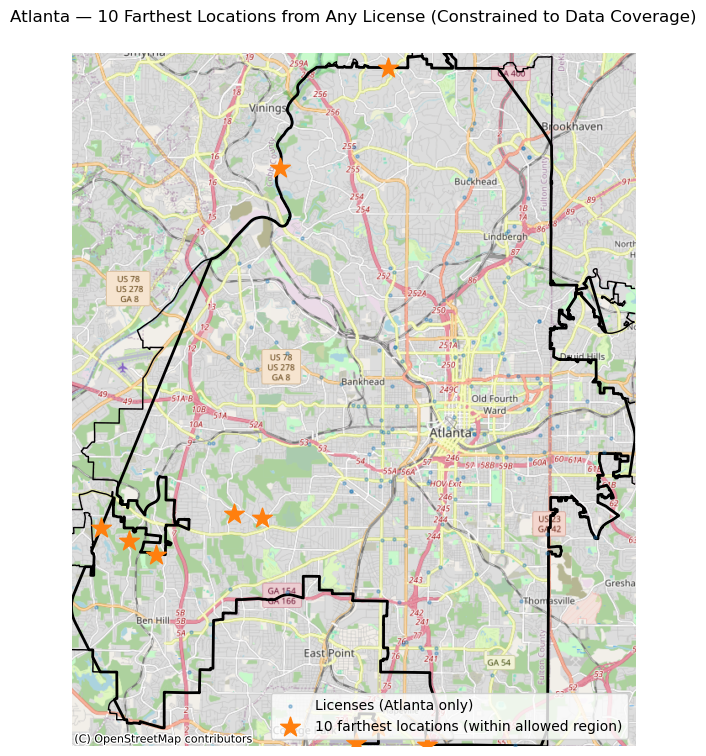

 star_latitude  star_longitude  distance_to_nearest_license_km
     33.648929      -84.428062                        4.143732
     33.648418      -84.399061                        3.302287
     33.654414      -84.419151                        3.277503
     33.878123      -84.414963                        3.254509
     33.712991      -84.509934                        2.998710
     33.722111      -84.532167                        2.932933
     33.725380      -84.466527                        2.930775
     33.726689      -84.478053                        2.794693
     33.717694      -84.521033                        2.780137
     33.844398      -84.459070                        2.772624

Points inside Atlanta city limits: 161 / 161


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import geopandas as gpd
from shapely.geometry import Point
import contextily as ctx

from sklearn.neighbors import BallTree

# -----------------------------
# 1) Load & clean licenses
# -----------------------------
df = pd.read_csv("Atlanta_Business_License_Records_2025.xlsx - Filtered_Fresh_Food.csv")
df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")
df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")
df = df.dropna(subset=["latitude", "longitude"]).copy()

licenses = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
    crs="EPSG:4326"
)

# -----------------------------
# 2) Atlanta boundary (City limits)
# -----------------------------
tiger_places_url = "https://www2.census.gov/geo/tiger/TIGER2024/PLACE/tl_2024_13_place.zip"
places = gpd.read_file(tiger_places_url).to_crs("EPSG:4326")

atl = places[places["NAME"].str.upper().eq("ATLANTA")].copy()
atl_geom = atl.dissolve().geometry.iloc[0]  # single polygon

# Keep only points inside city limits (sanity)
licenses_city = licenses[licenses.within(atl_geom)].copy()
if len(licenses_city) == 0:
    raise ValueError("0 points inside Atlanta city limits — check lat/lon columns or CRS.")

# -----------------------------
# 3) Define "data coverage area" = buffered convex hull of your points
#    (prevents stars landing in parts of the city your data doesn't cover)
# -----------------------------
hull = licenses_city.unary_union.convex_hull
coverage = hull.buffer(0.01)  # ~ about 1km buffer-ish (degree-based). Adjust: 0.005–0.02

# Final allowed region for stars:
allowed_region = atl_geom.intersection(coverage)

# -----------------------------
# 4) Sample candidate points ONLY inside allowed_region
# -----------------------------
minx, miny, maxx, maxy = allowed_region.bounds  # lon/lat
num_candidates = 60000
batch = 25000

cand_points = []
while len(cand_points) < num_candidates:
    xs = np.random.uniform(minx, maxx, size=batch)
    ys = np.random.uniform(miny, maxy, size=batch)

    pts = gpd.GeoSeries([Point(x, y) for x, y in zip(xs, ys)], crs="EPSG:4326")
    inside = pts.within(allowed_region)
    kept = pts[inside]
    cand_points.extend(list(kept))

cand_points = cand_points[:num_candidates]
cand_latlon = np.array([(p.y, p.x) for p in cand_points])  # (lat, lon)

# -----------------------------
# 5) Nearest-license distance (haversine BallTree)
# -----------------------------
license_latlon = licenses_city[["latitude", "longitude"]].to_numpy()
tree = BallTree(np.radians(license_latlon), metric="haversine")

dist_rad, _ = tree.query(np.radians(cand_latlon), k=1)
dist_km = dist_rad[:, 0] * 6371.0088

# -----------------------------
# 6) Pick top 10 with spacing
# -----------------------------
order = np.argsort(-dist_km)
picked = []
min_sep_km = 1.0  # keep stars separated

def approx_km_between(a, b):
    lat1, lon1 = a
    lat2, lon2 = b
    dlat_km = abs(lat1 - lat2) * 111.0
    dlon_km = abs(lon1 - lon2) * 111.0 * np.cos(np.radians((lat1 + lat2) / 2))
    return np.sqrt(dlat_km**2 + dlon_km**2)

for idx in order:
    pt = cand_latlon[idx]  # (lat, lon)
    if all(approx_km_between(pt, p[0]) >= min_sep_km for p in picked):
        picked.append((pt, dist_km[idx]))
    if len(picked) == 10:
        break

stars_lat = np.array([p[0][0] for p in picked])
stars_lon = np.array([p[0][1] for p in picked])
stars_km  = np.array([p[1] for p in picked])

stars = gpd.GeoDataFrame(
    {"dist_km": stars_km},
    geometry=gpd.points_from_xy(stars_lon, stars_lat),
    crs="EPSG:4326"
)

# -----------------------------
# 7) Plot with basemap
# -----------------------------
licenses_web = licenses_city.to_crs(epsg=3857)
stars_web = stars.to_crs(epsg=3857)

atl_web = gpd.GeoSeries([atl_geom], crs="EPSG:4326").to_crs(epsg=3857)
allowed_web = gpd.GeoSeries([allowed_region], crs="EPSG:4326").to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(9, 9))

# City boundary (thin)
atl_web.plot(ax=ax, facecolor="none", linewidth=1)

# Coverage/allowed region (helps you visually confirm constraint)
allowed_web.plot(ax=ax, facecolor="none", linewidth=2)

# Points + stars
licenses_web.plot(ax=ax, markersize=5, alpha=0.35, label="Licenses (Atlanta only)")
stars_web.plot(ax=ax, markersize=220, marker="*", label="10 farthest locations (within allowed region)")

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

# Zoom to allowed region so it never looks "outside Atlanta"
minx, miny, maxx, maxy = allowed_web.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ax.set_axis_off()
ax.set_title("Atlanta — 10 Farthest Locations from Any License (Constrained to Data Coverage)", pad=12)
ax.legend()
plt.show()

# -----------------------------
# 8) Output star coords + distances
# -----------------------------
out = pd.DataFrame({
    "star_latitude": stars_lat,
    "star_longitude": stars_lon,
    "distance_to_nearest_license_km": stars_km
}).sort_values("distance_to_nearest_license_km", ascending=False)

print(out.to_string(index=False))
print(f"\nPoints inside Atlanta city limits: {len(licenses_city)} / {len(licenses)}")

Total points: 161
Points > 0.5 miles from nearest store: 34


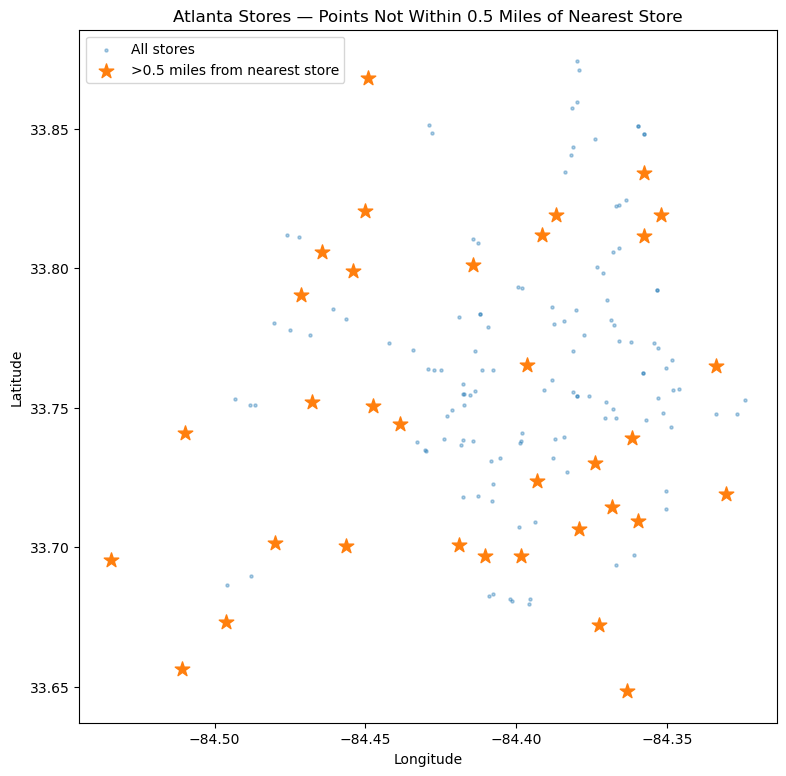

Exported starred points to: stores_farther_than_0_5_miles.csv


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# If you get an import error, install with:
#   pip install scikit-learn
from sklearn.neighbors import BallTree

# -----------------------------
# 1) Load & clean
# -----------------------------
df = pd.read_csv("Atlanta_Business_License_Records_2025.xlsx - Filtered_Fresh_Food.csv")

df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")
df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")
df = df.dropna(subset=["latitude", "longitude"]).copy()

# -----------------------------
# 2) Nearest-neighbor distance (exclude itself)
# -----------------------------
coords = df[["latitude", "longitude"]].to_numpy()
tree = BallTree(np.radians(coords), metric="haversine")

# k=2 gives: [0] = itself (distance 0), [1] = nearest OTHER point
dist_rad, ind = tree.query(np.radians(coords), k=2)
nearest_km = dist_rad[:, 1] * 6371.0088

# Convert to miles
nearest_miles = nearest_km * 0.621371
df["nearest_store_miles"] = nearest_miles

# -----------------------------
# 3) Flag points farther than 0.5 miles from nearest other point
# -----------------------------
threshold_miles = 0.5
far = df[df["nearest_store_miles"] > threshold_miles].copy()

print(f"Total points: {len(df)}")
print(f"Points > {threshold_miles} miles from nearest store: {len(far)}")

# -----------------------------
# 4) Plot (original scatter + stars)
# -----------------------------
plt.figure(figsize=(9, 9))

# All points
plt.scatter(df["longitude"], df["latitude"], s=5, alpha=0.35, label="All stores")

# Star the isolated ones
plt.scatter(far["longitude"], far["latitude"], s=120, marker="*", label=f">{threshold_miles} miles from nearest store")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Atlanta Stores — Points Not Within 0.5 Miles of Nearest Store")
plt.legend()
plt.show()

# -----------------------------
# 5) Optional: export the starred points
# -----------------------------
far.to_csv("stores_farther_than_0_5_miles.csv", index=False)
print("Exported starred points to: stores_farther_than_0_5_miles.csv")

In [14]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# If you get an import error here, run: pip install scikit-learn
from sklearn.neighbors import BallTree

# -----------------------------
# 1) Load & clean
# -----------------------------
df = pd.read_csv("Atlanta_Business_License_Records_2025.xlsx - Filtered_Fresh_Food.csv")

df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")
df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")
df = df.dropna(subset=["latitude", "longitude"]).copy()

# -----------------------------
# 2) Nearest-neighbor distance (exclude itself)
# -----------------------------
coords = df[["latitude", "longitude"]].to_numpy()

tree = BallTree(np.radians(coords), metric="haversine")
# k=2 => nearest is itself (0), second is nearest OTHER point
dist_rad, _ = tree.query(np.radians(coords), k=2)

nearest_km = dist_rad[:, 1] * 6371.0088
nearest_miles = nearest_km * 0.621371

df["nearest_other_miles"] = nearest_miles

# Star any point whose nearest other point is > 0.5 miles away
threshold_miles = 0.5
far = df[df["nearest_other_miles"] > threshold_miles].copy()

print(f"Total points: {len(df)}")
print(f"Starred points (> {threshold_miles} miles from nearest other point): {len(far)}")

# -----------------------------
# 3) Plot on Atlanta basemap (OpenStreetMap)
# -----------------------------
center_lat = float(df["latitude"].median())
center_lon = float(df["longitude"].median())

fig = go.Figure()

# All points
fig.add_trace(go.Scattermapbox(
    lat=df["latitude"],
    lon=df["longitude"],
    mode="markers",
    marker=dict(size=5, opacity=0.35),
    name="All licenses"
))

# Starred points
fig.add_trace(go.Scattermapbox(
    lat=far["latitude"],
    lon=far["longitude"],
    mode="markers",
    marker=dict(size=14, symbol="star"),
    name=f"Isolated (> {threshold_miles} mi)"
))

fig.update_layout(
    mapbox_style="open-street-map",
    mapbox_center={"lat": center_lat, "lon": center_lon},
    mapbox_zoom=10.5,
    height=800,
    title=f"Atlanta — Points Not Within {threshold_miles} Miles of Nearest License"
)

fig.show()

# -----------------------------
# 4) Optional: export starred points
# -----------------------------
far.to_csv("isolated_points_over_0_5_miles.csv", index=False)
print("Saved: isolated_points_over_0_5_miles.csv")

Total points: 161
Starred points (> 0.5 miles from nearest other point): 34


Saved: isolated_points_over_0_5_miles.csv


In [15]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from sklearn.neighbors import BallTree

# -----------------------------
# Load & clean
# -----------------------------
df = pd.read_csv("Atlanta_Business_License_Records_2025.xlsx - Filtered_Fresh_Food.csv")

df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")
df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")
df = df.dropna(subset=["latitude", "longitude"]).copy()

# -----------------------------
# Nearest-neighbor distance (exclude itself)
# -----------------------------
coords = df[["latitude", "longitude"]].to_numpy()
tree = BallTree(np.radians(coords), metric="haversine")

dist_rad, _ = tree.query(np.radians(coords), k=2)
nearest_km = dist_rad[:, 1] * 6371.0088
df["nearest_other_miles"] = nearest_km * 0.621371

threshold_miles = 0.5
far = df[df["nearest_other_miles"] > threshold_miles].copy()

print(f"Starred points (> {threshold_miles} miles): {len(far)}")

# -----------------------------
# Plot on Atlanta basemap
# -----------------------------
center_lat = float(df["latitude"].median())
center_lon = float(df["longitude"].median())

fig = go.Figure()

# All points (faint background)
fig.add_trace(go.Scattermapbox(
    lat=df["latitude"],
    lon=df["longitude"],
    mode="markers",
    marker=dict(size=5, opacity=0.25),
    name="All licenses"
))

# "Outline" layer: bigger black stars underneath
fig.add_trace(go.Scattermapbox(
    lat=far["latitude"],
    lon=far["longitude"],
    mode="markers",
    marker=dict(size=34, symbol="star", color="black", opacity=1),
    name="Isolated (outline)"
))

# Top layer: slightly smaller red stars
fig.add_trace(go.Scattermapbox(
    lat=far["latitude"],
    lon=far["longitude"],
    mode="markers",
    marker=dict(size=26, symbol="star", color="red", opacity=1),
    name=f"Isolated > {threshold_miles} mi"
))

fig.update_layout(
    mapbox_style="open-street-map",
    mapbox_center={"lat": center_lat, "lon": center_lon},
    mapbox_zoom=10.5,
    height=850,
    title=f"Atlanta — Points Not Within {threshold_miles} Miles of Nearest License",
    legend=dict(orientation="h", yanchor="bottom", y=0.01, xanchor="left", x=0.01)
)

import plotly.graph_objects as go

center_lat = float(df["latitude"].median())
center_lon = float(df["longitude"].median())

fig = go.Figure()

# All points (background)
fig.add_trace(go.Scattermapbox(
    lat=df["latitude"],
    lon=df["longitude"],
    mode="markers",
    marker=dict(size=10, opacity=0.25),
    name="All licenses"
))

# OUTLINE layer: big black star text
fig.add_trace(go.Scattermapbox(
    lat=far["latitude"],
    lon=far["longitude"],
    mode="text",
    text=["★"] * len(far),
    textfont=dict(size=28, color="black"),
    name="Isolated (outline)"
))

# TOP layer: slightly smaller red star text
fig.add_trace(go.Scattermapbox(
    lat=far["latitude"],
    lon=far["longitude"],
    mode="text",
    text=["★"] * len(far),
    textfont=dict(size=22, color="red"),
    name="Isolated > 0.5 mi"
))

fig.update_layout(
    mapbox_style="open-street-map",
    mapbox_center={"lat": center_lat, "lon": center_lon},
    mapbox_zoom=10.5,
    height=850,
    title="Atlanta — Points Not Within 0.5 Miles of Nearest License",
    legend=dict(orientation="h", yanchor="bottom", y=0.01, xanchor="left", x=0.01)
)


fig.show()

Starred points (> 0.5 miles): 34


In [16]:
import plotly.graph_objects as go

center_lat = float(df["latitude"].median())
center_lon = float(df["longitude"].median())

fig = go.Figure()

# Background: all points small + faint
fig.add_trace(go.Scattermapbox(
    lat=df["latitude"],
    lon=df["longitude"],
    mode="markers",
    marker=dict(size=4, opacity=0.18, color="blue"),
    name="All licenses"
))

# Isolated points: BIG bright markers with thick outline
fig.add_trace(go.Scattermapbox(
    lat=far["latitude"],
    lon=far["longitude"],
    mode="markers",
    marker=dict(
        size=18,           # bigger
        color="yellow",    # high contrast vs map
        opacity=1
    ),
    name="Isolated (> 0.5 mi)"
))

# Fake "outline" by drawing a slightly bigger black circle underneath
fig.add_trace(go.Scattermapbox(
    lat=far["latitude"],
    lon=far["longitude"],
    mode="markers",
    marker=dict(
        size=26,           # bigger than yellow => acts like outline
        color="black",
        opacity=1
    ),
    name="Isolated (outline)"
))

# Put outline BELOW the yellow marker by reordering traces:
# Actually: add outline first, then yellow on top (so swap order)
fig.data = (fig.data[0], fig.data[2], fig.data[1])

fig.update_layout(
    mapbox_style="open-street-map",
    mapbox_center={"lat": center_lat, "lon": center_lon},
    mapbox_zoom=10.5,
    height=850,
    title="Atlanta — Points Not Within 0.5 Miles of Nearest License",
    legend=dict(orientation="h", yanchor="bottom", y=0.01, xanchor="left", x=0.01)
)

fig.show()

In [17]:

# Dependencies:
# pip install pandas numpy geopandas shapely plotly

import os
import urllib.request
import tempfile
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, Polygon, MultiPolygon
from shapely.ops import unary_union
import plotly.graph_objects as go

# ---------------------------
# Config
# ---------------------------
CSV_PATH = "Atlanta_Business_License_Records_2025.xlsx - Filtered_Fresh_Food.csv"
TIGER_PLACE_URL = "https://www2.census.gov/geo/tiger/TIGER2024/PLACE/tl_2024_13_place.zip"
R_MILES = 0.5
R_METERS = R_MILES * 1609.344

# Performance / plotting controls
MARKER_SAMPLE_N = 2000                  # marker downsampling for visualization only
COVERAGE_USE_SAMPLE_IF_LARGE = False    # set True if coverage is too slow on all points
COVERAGE_MAX_POINTS = 5000              # used only if COVERAGE_USE_SAMPLE_IF_LARGE=True
SIMPLIFY_TOLERANCE_M = 30               # simplification in projected CRS (meters)

# ---------------------------
# Helpers
# ---------------------------
def load_atlanta_boundary(url: str) -> gpd.GeoDataFrame:
    """Load Atlanta city boundary from TIGER Places (Georgia), dissolved to single geometry."""
    # Robust approach: download zip then read locally
    with tempfile.TemporaryDirectory() as td:
        zip_path = os.path.join(td, "tl_2024_13_place.zip")
        urllib.request.urlretrieve(url, zip_path)
        places = gpd.read_file(zip_path)
    atl = places.loc[places["NAME"] == "Atlanta"].copy()
    if atl.empty:
        raise ValueError("Could not find NAME == 'Atlanta' in TIGER Places data.")
    atl = atl.to_crs("EPSG:4326")
    atl = atl.dissolve().reset_index(drop=True)
    atl["geometry"] = atl.geometry.buffer(0)  # fix any minor invalidity
    return atl

def geometry_to_rings(geom):
    """Yield exterior rings (lon, lat) for Polygon/MultiPolygon."""
    if geom is None or geom.is_empty:
        return
    if isinstance(geom, Polygon):
        x, y = geom.exterior.coords.xy
        yield list(x), list(y)
    elif isinstance(geom, MultiPolygon):
        for poly in geom.geoms:
            if not poly.is_empty:
                x, y = poly.exterior.coords.xy
                yield list(x), list(y)
    else:
        # Attempt to iterate generic geometry collection
        try:
            for g in geom.geoms:
                if isinstance(g, (Polygon, MultiPolygon)):
                    yield from geometry_to_rings(g)
        except Exception:
            return

# ---------------------------
# A) Read CSV + clean coords
# ---------------------------
df = pd.read_csv(CSV_PATH)
df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")
df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")
df = df.dropna(subset=["latitude", "longitude"]).copy()

if df.empty:
    raise ValueError("No valid latitude/longitude rows after coercion.")

# ---------------------------
# B) Store points GeoDataFrame (EPSG:4326)
# ---------------------------
stores = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
    crs="EPSG:4326",
)

# ---------------------------
# C) Atlanta boundary + filter points within city
# ---------------------------
atlanta = load_atlanta_boundary(TIGER_PLACE_URL)
atl_geom_wgs84 = atlanta.geometry.iloc[0]

stores_in_atl = stores[stores.geometry.within(atl_geom_wgs84)].copy()

if stores_in_atl.empty:
    raise ValueError("No store points found within Atlanta city limits.")

# ---------------------------
# D) Reproject to metric CRS (EPSG:3857)
# ---------------------------
atlanta_3857 = atlanta.to_crs("EPSG:3857")
stores_3857 = stores_in_atl.to_crs("EPSG:3857")
atl_geom_3857 = atlanta_3857.geometry.iloc[0]

# ---------------------------
# E/F/G) Buffers, union, uncovered target
# ---------------------------
coverage_points_3857 = stores_3857
if COVERAGE_USE_SAMPLE_IF_LARGE and len(stores_3857) > COVERAGE_MAX_POINTS:
    coverage_points_3857 = stores_3857.sample(COVERAGE_MAX_POINTS, random_state=42)

buffers = coverage_points_3857.geometry.buffer(R_METERS)
coverage_union = unary_union(buffers.values)
coverage_in_city = atl_geom_3857.intersection(coverage_union)
target_geom_3857 = atl_geom_3857.difference(coverage_union)

# Simplify for plotting/export performance
coverage_in_city = coverage_in_city.simplify(SIMPLIFY_TOLERANCE_M, preserve_topology=True)
target_geom_3857 = target_geom_3857.simplify(SIMPLIFY_TOLERANCE_M, preserve_topology=True)

# Reproject coverage/target back to EPSG:4326
coverage_gdf_wgs84 = gpd.GeoDataFrame(geometry=[coverage_in_city], crs="EPSG:3857").to_crs("EPSG:4326")
target_gdf_wgs84 = gpd.GeoDataFrame(geometry=[target_geom_3857], crs="EPSG:3857").to_crs("EPSG:4326")
coverage_wgs84 = coverage_gdf_wgs84.geometry.iloc[0]
target_wgs84 = target_gdf_wgs84.geometry.iloc[0]

# ---------------------------
# Stats
# ---------------------------
atl_area_sqkm = atl_geom_3857.area / 1e6
coverage_area_sqkm = coverage_in_city.area / 1e6
uncovered_area_sqkm = target_geom_3857.area / 1e6
pct_covered = (coverage_area_sqkm / atl_area_sqkm * 100.0) if atl_area_sqkm > 0 else 0.0

# ---------------------------
# Marker downsample for visualization only
# ---------------------------
stores_plot = stores_in_atl
if len(stores_plot) > MARKER_SAMPLE_N:
    stores_plot = stores_plot.sample(MARKER_SAMPLE_N, random_state=42)

center_lat = float(np.median(stores_in_atl["latitude"]))
center_lon = float(np.median(stores_in_atl["longitude"]))

# ---------------------------
# Plotly map (OpenStreetMap style, no token required)
# ---------------------------
fig = go.Figure()

# 1) Store points
fig.add_trace(
    go.Scattermapbox(
        lat=stores_plot["latitude"],
        lon=stores_plot["longitude"],
        mode="markers",
        marker=dict(size=5, color="#1f77b4", opacity=0.9),
        name="Stores",
        hovertemplate="Store<br>Lat: %{lat:.5f}<br>Lon: %{lon:.5f}<extra></extra>",
        showlegend=True,
    )
)

# 2) Coverage polygons
first_cov = True
for lons, lats in geometry_to_rings(coverage_wgs84):
    fig.add_trace(
        go.Scattermapbox(
            lon=lons,
            lat=lats,
            mode="lines",
            line=dict(width=1, color="rgba(20,130,20,0.45)"),
            fill="toself",
            fillcolor="rgba(20,180,20,0.25)",
            name=f"Coverage ({R_MILES} miles)",
            hoverinfo="skip",
            showlegend=first_cov,
        )
    )
    first_cov = False

# 3) Target (uncovered) polygons
first_tgt = True
for lons, lats in geometry_to_rings(target_wgs84):
    fig.add_trace(
        go.Scattermapbox(
            lon=lons,
            lat=lats,
            mode="lines",
            line=dict(width=1, color="rgba(170,0,0,0.8)"),
            fill="toself",
            fillcolor="rgba(220,0,0,0.45)",
            name="Target (uncovered)",
            text=["Uncovered target area"] * len(lons),
            hovertemplate="%{text}<extra></extra>",
            showlegend=first_tgt,
        )
    )
    first_tgt = False

fig.update_layout(
    mapbox=dict(
        style="open-street-map",
        center=dict(lat=center_lat, lon=center_lon),
        zoom=10.8,
    ),
    margin=dict(l=10, r=10, t=40, b=10),
    title=f"Fresh Food Access Coverage in Atlanta (R = {R_MILES} miles)",
    legend=dict(orientation="h", y=0.01, x=0.01),
)

fig.show()

# ---------------------------
# Save uncovered target polygons
# ---------------------------
target_out = gpd.GeoDataFrame(
    {"label": ["Uncovered target area"]},
    geometry=[target_wgs84],
    crs="EPSG:4326",
)
target_out.to_file("atlanta_uncovered_targets.geojson", driver="GeoJSON")

# ---------------------------
# Print summary
# ---------------------------
print(f"Stores in Atlanta: {len(stores_in_atl):,}")
print(f"Radius used: {R_MILES} miles ({R_METERS:.2f} meters)")
print(f"Atlanta area: {atl_area_sqkm:,.2f} sq km")
print(f"Coverage area (within Atlanta): {coverage_area_sqkm:,.2f} sq km")
print(f"Uncovered area: {uncovered_area_sqkm:,.2f} sq km")
print(f"Percent covered: {pct_covered:.2f}%")
print("Saved uncovered targets: atlanta_uncovered_targets.geojson")


Stores in Atlanta: 161
Radius used: 0.5 miles (804.67 meters)
Atlanta area: 512.41 sq km
Coverage area (within Atlanta): 185.08 sq km
Uncovered area: 327.42 sq km
Percent covered: 36.12%
Saved uncovered targets: atlanta_uncovered_targets.geojson


In [18]:
import os
size_mb = os.path.getsize("atlanta_uncovered_targets.geojson") / 1e6
print(f"File size: {size_mb:.1f} MB")

File size: 0.1 MB


In [19]:
import os
import urllib.request
import tempfile
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, Polygon, MultiPolygon
from shapely.ops import unary_union

# ---------------------------
# Config
# ---------------------------
CSV_PATH = "Atlanta_Business_License_Records_2025.xlsx - Filtered_Fresh_Food.csv"
TIGER_PLACE_URL = "https://www2.census.gov/geo/tiger/TIGER2024/PLACE/tl_2024_13_place.zip"
R_MILES = 0.5
R_METERS = R_MILES * 1609.344
MARTA_R_MILES = 0.25
MARTA_R_METERS = MARTA_R_MILES * 1609.344
SIMPLIFY_TOLERANCE_M = 100

# ---------------------------
# A) Read CSV
# ---------------------------
df = pd.read_csv(CSV_PATH)
df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")
df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")
df = df.dropna(subset=["latitude", "longitude"]).copy()
print(f"A done. {len(df)} rows loaded.")

# ---------------------------
# B) Store points
# ---------------------------
stores = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
    crs="EPSG:4326",
)
print(f"B done. {len(stores)} stores.")

# ---------------------------
# C) Atlanta boundary
# ---------------------------
# Rough Atlanta city bounding box
ZIP_LOCAL = "tl_2024_13_place.zip"

if not os.path.exists(ZIP_LOCAL):
    print("Downloading TIGER file (one time only)...")
    urllib.request.urlretrieve(TIGER_PLACE_URL, ZIP_LOCAL)

places = gpd.read_file(ZIP_LOCAL)
atlanta = places.loc[places["NAME"] == "Atlanta"].copy()
atlanta = atlanta.to_crs("EPSG:4326").dissolve().reset_index(drop=True)
atlanta["geometry"] = atlanta.geometry.buffer(0)
atl_geom_wgs84 = atlanta.geometry.iloc[0]

stores_in_atl = stores[stores.geometry.within(atl_geom_wgs84)].copy()
print(f"C done. {len(stores_in_atl)} stores in Atlanta.")
# ---------------------------
# D) Reproject
# ---------------------------
atlanta_3857 = atlanta.to_crs("EPSG:3857")
stores_3857 = stores_in_atl.to_crs("EPSG:3857")
atl_geom_3857 = atlanta_3857.geometry.iloc[0]
print("D done. Reprojected.")

# ---------------------------
# E) Store buffers — low resolution for speed
# ---------------------------
print("Starting store buffers...")
buffers = stores_3857.geometry.buffer(R_METERS, resolution=4)
print("Buffers created.")
coverage_union = unary_union(buffers.values)
print("Union done.")

coverage_in_city = atl_geom_3857.intersection(coverage_union)
target_geom_3857 = atl_geom_3857.difference(coverage_union)
print("E done. Coverage computed.")

# ---------------------------
# F) Simplify before anything else touches these
# ---------------------------
target_geom_3857 = target_geom_3857.simplify(SIMPLIFY_TOLERANCE_M, preserve_topology=True)
coverage_in_city = coverage_in_city.simplify(SIMPLIFY_TOLERANCE_M, preserve_topology=True)
print("F done. Simplified.")

# ---------------------------
# G) Stats
# ---------------------------
atl_area_sqkm = atl_geom_3857.area / 1e6
coverage_area_sqkm = coverage_in_city.area / 1e6
uncovered_area_sqkm = target_geom_3857.area / 1e6
pct_covered = coverage_area_sqkm / atl_area_sqkm * 100.0
print(f"G done. {pct_covered:.1f}% covered.")

# ---------------------------
# H) MARTA stops
# ---------------------------
marta = gpd.read_file("marta_routes_overlay.geojson")
print(f"Loaded MARTA: {len(marta)} features")
print(f"Geometry types: {marta.geometry.type.unique()}")

marta = marta.to_crs("EPSG:3857")

# ---------------------------
# I) MARTA buffers
# ---------------------------
marta_buffers = marta.geometry.buffer(MARTA_R_METERS, resolution=4)
marta_coverage_union = unary_union(marta_buffers.values)
marta_simple = marta_coverage_union.simplify(SIMPLIFY_TOLERANCE_M, preserve_topology=True)
print("I done. MARTA buffers computed.")

# ---------------------------
# J) Classify red zones
# ---------------------------
desert_with_transit = target_geom_3857.intersection(marta_simple)
desert_no_transit = target_geom_3857.difference(marta_simple)
print("J done. Classification complete.")

# ---------------------------
# K) Save GeoJSON
# ---------------------------
combined = gpd.GeoDataFrame(
    {"type": ["grocery_coverage", "no_grocery_has_marta", "no_grocery_no_marta"]},
    geometry=[
        coverage_in_city.simplify(200, preserve_topology=True),
        desert_with_transit.simplify(200, preserve_topology=True),
        desert_no_transit.simplify(200, preserve_topology=True),
    ],
    crs="EPSG:3857",
).to_crs("EPSG:4326")

combined.to_file("atlanta_food_transit_combined.geojson", driver="GeoJSON")
print(f"K done. File size: {os.path.getsize('atlanta_food_transit_combined.geojson') / 1e6:.1f} MB")

# ---------------------------
# L) Final stats
# ---------------------------
desert_transit_sqkm = desert_with_transit.area / 1e6
desert_no_transit_sqkm = desert_no_transit.area / 1e6

print(f"\n=== RESULTS ===")
print(f"Stores in Atlanta: {len(stores_in_atl):,}")
print(f"MARTA routes loaded: {len(marta):,}")
print(f"Atlanta area: {atl_area_sqkm:,.2f} sq km")
print(f"Grocery coverage: {coverage_area_sqkm:,.2f} sq km ({pct_covered:.1f}%)")
print(f"Uncovered WITH MARTA: {desert_transit_sqkm:,.2f} sq km")
print(f"Uncovered NO MARTA: {desert_no_transit_sqkm:,.2f} sq km")
print(f"Critical gap % of city: {desert_no_transit_sqkm / atl_area_sqkm * 100:.2f}%")

A done. 161 rows loaded.
B done. 161 stores.
C done. 161 stores in Atlanta.
D done. Reprojected.
Starting store buffers...
Buffers created.
Union done.
E done. Coverage computed.
F done. Simplified.
G done. 34.5% covered.


Loaded MARTA: 118 features
Geometry types: ['MultiLineString']


I done. MARTA buffers computed.
J done. Classification complete.
K done. File size: 0.1 MB

=== RESULTS ===
Stores in Atlanta: 161
MARTA routes loaded: 118
Atlanta area: 512.41 sq km
Grocery coverage: 176.82 sq km (34.5%)
Uncovered WITH MARTA: 182.88 sq km
Uncovered NO MARTA: 151.70 sq km
Critical gap % of city: 29.61%


In [20]:
# ---------------------------
# M) Plot the map
# ---------------------------
import plotly.graph_objects as go

def geometry_to_rings(geom):
    if geom is None or geom.is_empty:
        return
    if isinstance(geom, Polygon):
        x, y = geom.exterior.coords.xy
        yield list(x), list(y)
    elif isinstance(geom, MultiPolygon):
        for poly in geom.geoms:
            if not poly.is_empty:
                x, y = poly.exterior.coords.xy
                yield list(x), list(y)

# Convert back to WGS84 for plotting
cov_wgs = gpd.GeoDataFrame(geometry=[coverage_in_city], crs="EPSG:3857").to_crs("EPSG:4326").geometry.iloc[0]
transit_wgs = gpd.GeoDataFrame(geometry=[desert_with_transit], crs="EPSG:3857").to_crs("EPSG:4326").geometry.iloc[0]
no_transit_wgs = gpd.GeoDataFrame(geometry=[desert_no_transit], crs="EPSG:3857").to_crs("EPSG:4326").geometry.iloc[0]

fig = go.Figure()

# Green — grocery coverage
first = True
for lons, lats in geometry_to_rings(cov_wgs):
    fig.add_trace(go.Scattermapbox(
        lon=lons, lat=lats, mode="lines", fill="toself",
        fillcolor="rgba(20,180,20,0.3)", line=dict(width=1, color="rgba(20,130,20,0.5)"),
        name="Grocery coverage", showlegend=first, hoverinfo="skip",
    ))
    first = False

# Yellow — no grocery but has MARTA
first = True
for lons, lats in geometry_to_rings(transit_wgs):
    fig.add_trace(go.Scattermapbox(
        lon=lons, lat=lats, mode="lines", fill="toself",
        fillcolor="rgba(255,193,7,0.5)", line=dict(width=1, color="rgba(200,150,0,0.7)"),
        name="No grocery, has MARTA", showlegend=first, hoverinfo="skip",
    ))
    first = False

# Red — no grocery, no MARTA (critical)
first = True
for lons, lats in geometry_to_rings(no_transit_wgs):
    fig.add_trace(go.Scattermapbox(
        lon=lons, lat=lats, mode="lines", fill="toself",
        fillcolor="rgba(220,0,0,0.45)", line=dict(width=1, color="rgba(170,0,0,0.8)"),
        name="No grocery, no MARTA", showlegend=first, hoverinfo="skip",
    ))
    first = False

# Store markers
fig.add_trace(go.Scattermapbox(
    lat=stores_in_atl["latitude"], lon=stores_in_atl["longitude"],
    mode="markers", marker=dict(size=5, color="#1f77b4"),
    name="Stores",
))

center_lat = float(np.median(stores_in_atl["latitude"]))
center_lon = float(np.median(stores_in_atl["longitude"]))

fig.update_layout(
    mapbox=dict(style="open-street-map", center=dict(lat=center_lat, lon=center_lon), zoom=11),
    margin=dict(l=10, r=10, t=40, b=10),
    title="Atlanta: Grocery + MARTA Coverage",
    legend=dict(orientation="h", y=0.01, x=0.01),
)

fig.show()

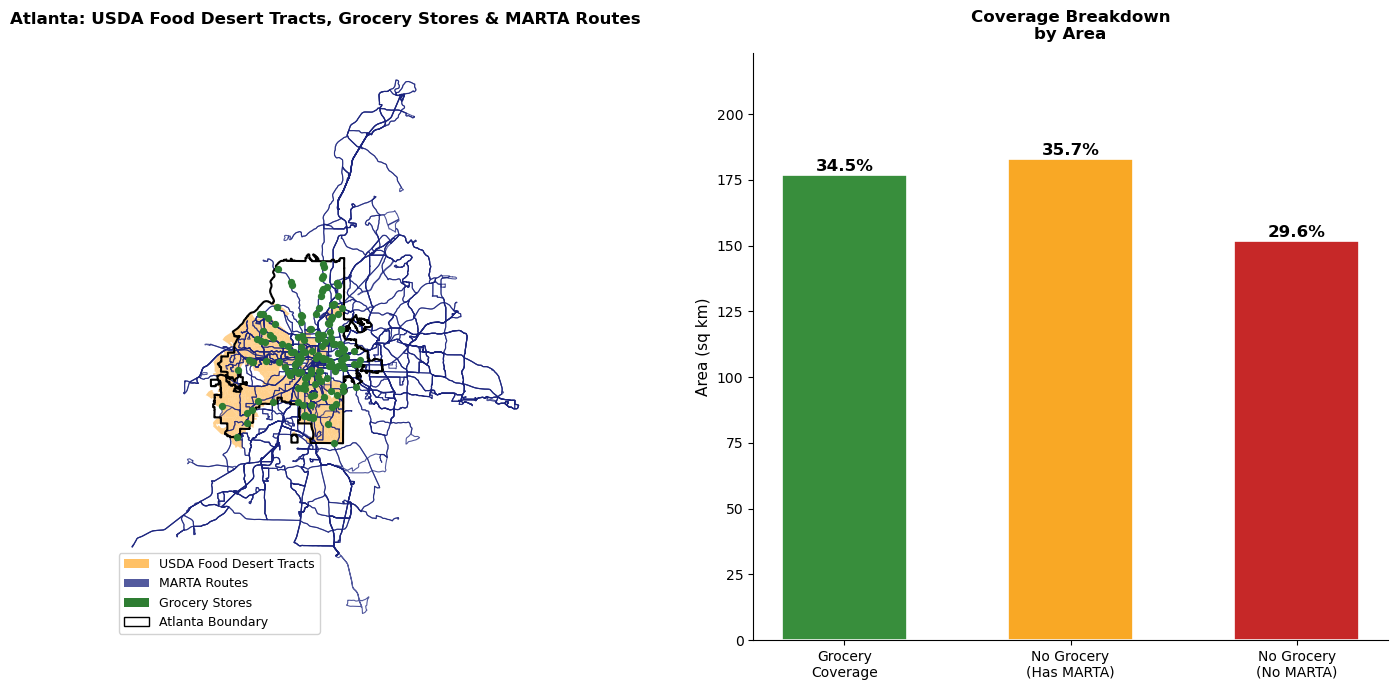

Saved: atlanta_coverage_summary.png


In [21]:
# ---------------------------
# N) Static summary figure: USDA Food Desert Tracts + Coverage Breakdown
# ---------------------------
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(16, 7))
gs = GridSpec(1, 2, width_ratios=[1.6, 1], figure=fig)

# --- Left: spatial map ---
ax_map = fig.add_subplot(gs[0])

# Reproject food deserts to match our working CRS
fd_3857 = food_deserts.to_crs("EPSG:3857")
fd_atl = fd_3857[fd_3857.geometry.intersects(atl_geom_3857)].copy()

# Atlanta boundary
atlanta_3857.boundary.plot(ax=ax_map, color="black", linewidth=1.5, zorder=4)

# USDA-designated food desert tracts
fd_atl.plot(ax=ax_map, color="#ff9800", alpha=0.45, edgecolor="none", zorder=2)

# MARTA routes
marta.plot(ax=ax_map, color="#1a237e", linewidth=0.8, alpha=0.75, zorder=3)

# Grocery stores
ax_map.scatter(
    stores_3857.geometry.x, stores_3857.geometry.y,
    color="#2e7d32", s=18, zorder=5,
)

ax_map.set_axis_off()
ax_map.set_title(
    "Atlanta: USDA Food Desert Tracts, Grocery Stores & MARTA Routes",
    fontsize=12, fontweight="bold", pad=10
)

legend_patches = [
    mpatches.Patch(facecolor="#ff9800", alpha=0.6, label="USDA Food Desert Tracts"),
    mpatches.Patch(facecolor="#1a237e", alpha=0.75, label="MARTA Routes"),
    mpatches.Patch(facecolor="#2e7d32", label="Grocery Stores"),
    mpatches.Patch(facecolor="white", edgecolor="black", label="Atlanta Boundary"),
]
ax_map.legend(handles=legend_patches, loc="lower left", fontsize=9, framealpha=0.88)

# --- Right: area breakdown bar chart ---
ax_bar = fig.add_subplot(gs[1])

labels = ["Grocery\nCoverage", "No Grocery\n(Has MARTA)", "No Grocery\n(No MARTA)"]
areas  = [coverage_area_sqkm, desert_transit_sqkm, desert_no_transit_sqkm]
colors = ["#388e3c", "#f9a825", "#c62828"]

bars = ax_bar.bar(labels, areas, color=colors, edgecolor="white", linewidth=1.2, width=0.55)

for bar, area in zip(bars, areas):
    pct = area / atl_area_sqkm * 100
    ax_bar.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.4,
        f"{pct:.1f}%",
        ha="center", va="bottom", fontsize=12, fontweight="bold"
    )

ax_bar.set_ylabel("Area (sq km)", fontsize=11)
ax_bar.set_title("Coverage Breakdown\nby Area", fontsize=12, fontweight="bold", pad=10)
ax_bar.set_ylim(0, max(areas) * 1.22)
ax_bar.spines[["top", "right"]].set_visible(False)
ax_bar.tick_params(axis="x", labelsize=10)

plt.tight_layout()
plt.savefig("atlanta_coverage_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: atlanta_coverage_summary.png")

In [22]:
# ---------------------------
# P) Red zones only — No Grocery + No MARTA
# ---------------------------
import plotly.graph_objects as go
import geopandas as gpd
import numpy as np

# Convert to WGS84 using the geometry_to_rings helper from cell M
no_transit_wgs = gpd.GeoDataFrame(
    geometry=[desert_no_transit], crs="EPSG:3857"
).to_crs("EPSG:4326").geometry.iloc[0]

fig2 = go.Figure()

first = True
for lons, lats in geometry_to_rings(no_transit_wgs):
    fig2.add_trace(go.Scattermapbox(
        lon=lons, lat=lats,
        mode="lines", fill="toself",
        fillcolor="rgba(220,0,0,0.5)",
        line=dict(width=1, color="rgba(140,0,0,0.9)"),
        name="No Grocery + No MARTA",
        showlegend=first,
        hoverinfo="skip",
    ))
    first = False

# Grocery stores for context — shows how far away coverage is
fig2.add_trace(go.Scattermapbox(
    lat=stores_in_atl["latitude"],
    lon=stores_in_atl["longitude"],
    mode="markers",
    marker=dict(size=6, color="#2ecc71"),
    name="Grocery Stores",
))

# Center on the bounding box of the red zones
bounds = no_transit_wgs.bounds
center_lat = (bounds[1] + bounds[3]) / 2
center_lon = (bounds[0] + bounds[2]) / 2

fig2.update_layout(
    mapbox=dict(
        style="open-street-map",
        center=dict(lat=center_lat, lon=center_lon),
        zoom=11,
    ),
    margin=dict(l=10, r=10, t=40, b=10),
    title="Atlanta: Critical Gaps — No Grocery Store & No MARTA Access",
    legend=dict(orientation="h", y=0.01, x=0.01),
)

fig2.show()


In [23]:
# ---------------------------
# Q) Red zones with labeled centroid markers
# ---------------------------
import plotly.graph_objects as go
import geopandas as gpd
import numpy as np
from shapely.geometry import MultiPolygon, Polygon

# Load red zones from saved file
combined = gpd.read_file("atlanta_food_transit_combined.geojson")
red_geom = combined[combined["type"] == "no_grocery_no_marta"].geometry.iloc[0]

polys = list(red_geom.geoms) if isinstance(red_geom, MultiPolygon) else [red_geom]

# Rank by area, keep significant zones
significant = []
for poly in sorted(polys, key=lambda p: p.area, reverse=True):
    area = gpd.GeoDataFrame(geometry=[poly], crs="EPSG:4326").to_crs("EPSG:3857").geometry.area.iloc[0] / 1e6
    if area >= 0.05:
        significant.append((poly, area))

fig3 = go.Figure()

# Draw red fill polygons
for i, (poly, area) in enumerate(significant):
    coords = list(poly.exterior.coords)
    lons = [c[0] for c in coords]
    lats = [c[1] for c in coords]
    fig3.add_trace(go.Scattermapbox(
        lon=lons, lat=lats,
        mode="lines", fill="toself",
        fillcolor="rgba(220,0,0,0.45)",
        line=dict(width=1, color="rgba(140,0,0,0.8)"),
        name="No Grocery + No MARTA" if i == 0 else "",
        showlegend=(i == 0),
        hoverinfo="skip",
    ))

# Centroid markers with zone labels
centroid_lats = [poly.centroid.y for poly, _ in significant]
centroid_lons = [poly.centroid.x for poly, _ in significant]
areas         = [area for _, area in significant]
labels        = [f"Zone {i+1}<br>{area:.2f} sq km" for i, area in enumerate(areas)]

fig3.add_trace(go.Scattermapbox(
    lat=centroid_lats,
    lon=centroid_lons,
    mode="markers+text",
    marker=dict(size=10, color="darkred", symbol="circle"),
    text=[str(i+1) for i in range(len(significant))],
    textposition="top right",
    hovertext=labels,
    hoverinfo="text",
    name="Zone Centroids",
))

# Grocery stores for context
fig3.add_trace(go.Scattermapbox(
    lat=stores_in_atl["latitude"],
    lon=stores_in_atl["longitude"],
    mode="markers",
    marker=dict(size=5, color="#2ecc71"),
    name="Grocery Stores",
))

center_lat = np.mean(centroid_lats[:6])
center_lon = np.mean(centroid_lons[:6])

fig3.update_layout(
    mapbox=dict(
        style="open-street-map",
        center=dict(lat=center_lat, lon=center_lon),
        zoom=11,
    ),
    margin=dict(l=10, r=10, t=40, b=10),
    title="Atlanta Critical Gaps — No Grocery & No MARTA (numbered by size)",
    legend=dict(orientation="h", y=0.01, x=0.01),
)

fig3.show()


In [24]:
# ---------------------------
# R) Red zones with population estimates
# ---------------------------
import plotly.graph_objects as go
import geopandas as gpd
import numpy as np
from shapely.geometry import MultiPolygon, Polygon

# --- Compute population per red zone ---
combined_gdf = gpd.read_file("atlanta_food_transit_combined.geojson")
red_geom = combined_gdf[combined_gdf["type"] == "no_grocery_no_marta"].geometry.iloc[0]
fd = food_deserts.to_crs("EPSG:4326")

polys = list(red_geom.geoms) if isinstance(red_geom, MultiPolygon) else [red_geom]
significant = []
for poly in sorted(polys, key=lambda p: p.area, reverse=True):
    area = gpd.GeoDataFrame(geometry=[poly], crs="EPSG:4326").to_crs("EPSG:3857").geometry.area.iloc[0] / 1e6
    if area >= 0.05:
        significant.append((poly, area))

zone_data = []
for i, (poly, area) in enumerate(significant):
    candidates = fd[fd.geometry.intersects(poly)].copy()
    pop_est = 0
    if not candidates.empty:
        for _, row in candidates.iterrows():
            intersection = row.geometry.intersection(poly)
            if row.geometry.area > 0:
                pop_est += row["POP10"] * (intersection.area / row.geometry.area)
    zone_data.append({
        "zone": i + 1,
        "lat": poly.centroid.y,
        "lon": poly.centroid.x,
        "area_sqkm": area,
        "population": int(round(pop_est)),
    })

total_pop = sum(z["population"] for z in zone_data)
print(f"Total estimated population in red zones: {total_pop:,}")

# --- Plot ---
fig4 = go.Figure()

# Red zone polygons
for i, (poly, _) in enumerate(significant):
    coords = list(poly.exterior.coords)
    fig4.add_trace(go.Scattermapbox(
        lon=[c[0] for c in coords],
        lat=[c[1] for c in coords],
        mode="lines", fill="toself",
        fillcolor="rgba(220,0,0,0.35)",
        line=dict(width=1, color="rgba(140,0,0,0.7)"),
        name="No Grocery + No MARTA" if i == 0 else "",
        showlegend=(i == 0),
        hoverinfo="skip",
    ))

# Centroid markers sized by population (min size 8 so zero-pop zones still show)
pop_vals  = [z["population"] for z in zone_data]
max_pop   = max(pop_vals) if max(pop_vals) > 0 else 1
sizes     = [max(8, 8 + 32 * (p / max_pop)) for p in pop_vals]
hover     = [
    f"Zone {z['zone']}<br>Population: {z['population']:,}<br>Area: {z['area_sqkm']:.2f} sq km"
    for z in zone_data
]

fig4.add_trace(go.Scattermapbox(
    lat=[z["lat"] for z in zone_data],
    lon=[z["lon"] for z in zone_data],
    mode="markers",
    marker=dict(
        size=sizes,
        color=pop_vals,
        colorscale="Reds",
        cmin=0,
        cmax=max_pop,
        colorbar=dict(title="Population", thickness=15),
        showscale=True,
    ),
    text=[str(z["zone"]) for z in zone_data],
    hovertext=hover,
    hoverinfo="text",
    name="Zone Population",
))

fig4.update_layout(
    mapbox=dict(
        style="open-street-map",
        center=dict(lat=np.mean([z["lat"] for z in zone_data[:6]]),
                    lon=np.mean([z["lon"] for z in zone_data[:6]])),
        zoom=11,
    ),
    margin=dict(l=10, r=10, t=50, b=10),
    title=f"Atlanta Critical Gaps — Estimated Population per Zone  (Total: {total_pop:,} residents)",
    legend=dict(orientation="h", y=0.01, x=0.01),
)

fig4.show()


Total estimated population in red zones: 22,937


In [25]:
# ---------------------------
# S) Critical gaps map — populated zones only (pop > 0)
# ---------------------------
import plotly.graph_objects as go
import geopandas as gpd
import numpy as np
from shapely.geometry import MultiPolygon, Polygon

# Recompute zone data (same as cell R)
combined_gdf = gpd.read_file("atlanta_food_transit_combined.geojson")
red_geom = combined_gdf[combined_gdf["type"] == "no_grocery_no_marta"].geometry.iloc[0]
fd = food_deserts.to_crs("EPSG:4326")

polys = list(red_geom.geoms) if isinstance(red_geom, MultiPolygon) else [red_geom]
significant = []
for poly in sorted(polys, key=lambda p: p.area, reverse=True):
    area = gpd.GeoDataFrame(geometry=[poly], crs="EPSG:4326").to_crs("EPSG:3857").geometry.area.iloc[0] / 1e6
    if area >= 0.05:
        significant.append((poly, area))

zone_data = []
for i, (poly, area) in enumerate(significant):
    candidates = fd[fd.geometry.intersects(poly)].copy()
    pop_est = 0
    if not candidates.empty:
        for _, row in candidates.iterrows():
            intersection = row.geometry.intersection(poly)
            if row.geometry.area > 0:
                pop_est += row["POP10"] * (intersection.area / row.geometry.area)
    zone_data.append({
        "zone": i + 1,
        "poly": poly,
        "lat": poly.centroid.y,
        "lon": poly.centroid.x,
        "area_sqkm": area,
        "population": int(round(pop_est)),
    })

# Filter to populated zones only
populated = [z for z in zone_data if z["population"] > 0]
print(f"Zones with population > 0: {len(populated)} of {len(zone_data)}")
print(f"Total population in populated zones: {sum(z['population'] for z in populated):,}")

fig5 = go.Figure()

# Red polygons — populated zones only
for i, z in enumerate(populated):
    coords = list(z["poly"].exterior.coords)
    fig5.add_trace(go.Scattermapbox(
        lon=[c[0] for c in coords],
        lat=[c[1] for c in coords],
        mode="lines", fill="toself",
        fillcolor="rgba(220,0,0,0.45)",
        line=dict(width=1, color="rgba(140,0,0,0.8)"),
        name="No Grocery + No MARTA" if i == 0 else "",
        showlegend=(i == 0),
        hoverinfo="skip",
    ))

# Markers sized by population
max_pop = max(z["population"] for z in populated)
sizes   = [8 + 32 * (z["population"] / max_pop) for z in populated]
hover   = [
    f"Zone {z['zone']}<br>Population: {z['population']:,}<br>Area: {z['area_sqkm']:.2f} sq km"
    for z in populated
]

fig5.add_trace(go.Scattermapbox(
    lat=[z["lat"] for z in populated],
    lon=[z["lon"] for z in populated],
    mode="markers",
    marker=dict(
        size=sizes,
        color=[z["population"] for z in populated],
        colorscale="Reds",
        colorbar=dict(title="Population", thickness=15),
        showscale=True,
    ),
    hovertext=hover,
    hoverinfo="text",
    name="Zone Population",
))

fig5.update_layout(
    mapbox=dict(
        style="open-street-map",
        center=dict(lat=np.mean([z["lat"] for z in populated]),
                    lon=np.mean([z["lon"] for z in populated])),
        zoom=11,
    ),
    margin=dict(l=10, r=10, t=50, b=10),
    title=f"Populated Critical Gaps — No Grocery & No MARTA  ({len(populated)} zones, {sum(z['population'] for z in populated):,} residents)",
    legend=dict(orientation="h", y=0.01, x=0.01),
)

fig5.show()


Zones with population > 0: 40 of 65
Total population in populated zones: 22,937


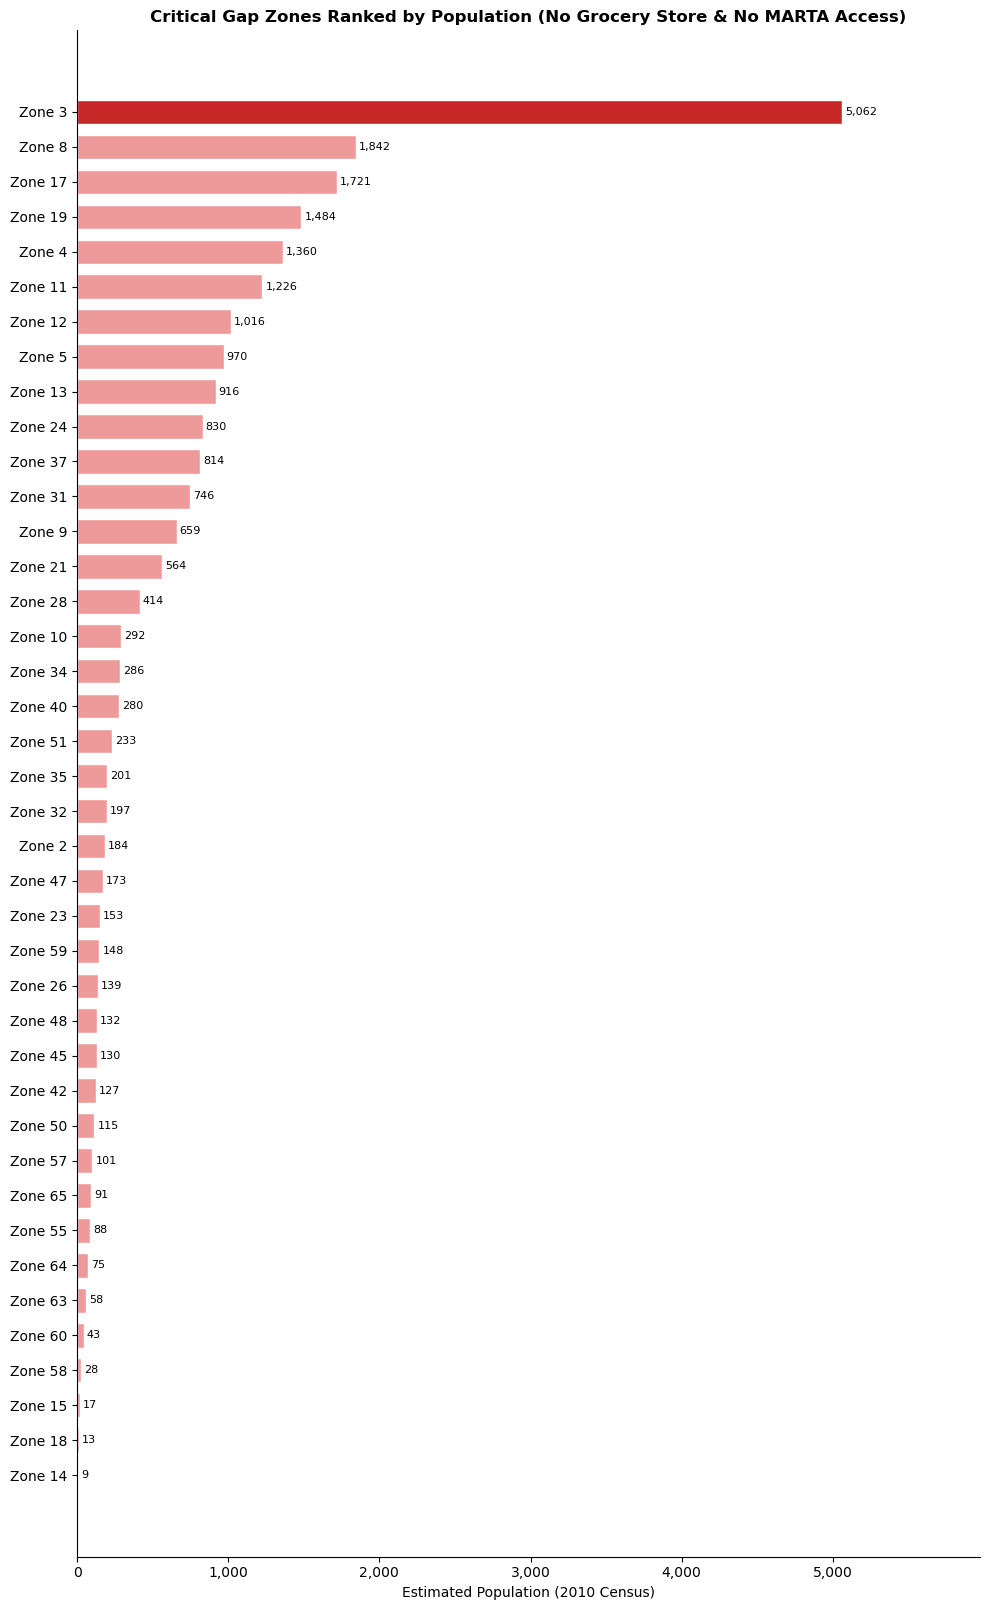

Total residents affected: 22,937 across 40 zones


In [26]:
# ---------------------------
# T) Populated zones ranked by population
# ---------------------------
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

ranked = sorted([z for z in populated], key=lambda z: z["population"], reverse=True)

labels = [f"Zone {z['zone']}" for z in ranked]
pops   = [z["population"] for z in ranked]
colors = ["#c62828" if p == max(pops) else "#ef9a9a" for p in pops]

fig, ax = plt.subplots(figsize=(10, len(ranked) * 0.38 + 1))

bars = ax.barh(labels[::-1], pops[::-1], color=colors[::-1], edgecolor="white", height=0.7)

for bar, pop in zip(bars, pops[::-1]):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
            f"{pop:,}", va="center", fontsize=8)

ax.set_xlabel("Estimated Population (2010 Census)", fontsize=10)
ax.set_title("Critical Gap Zones Ranked by Population (No Grocery Store & No MARTA Access)",
             fontsize=12, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlim(0, max(pops) * 1.18)

plt.tight_layout()
plt.savefig("zones_ranked_by_population.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Total residents affected: {sum(pops):,} across {len(ranked)} zones")


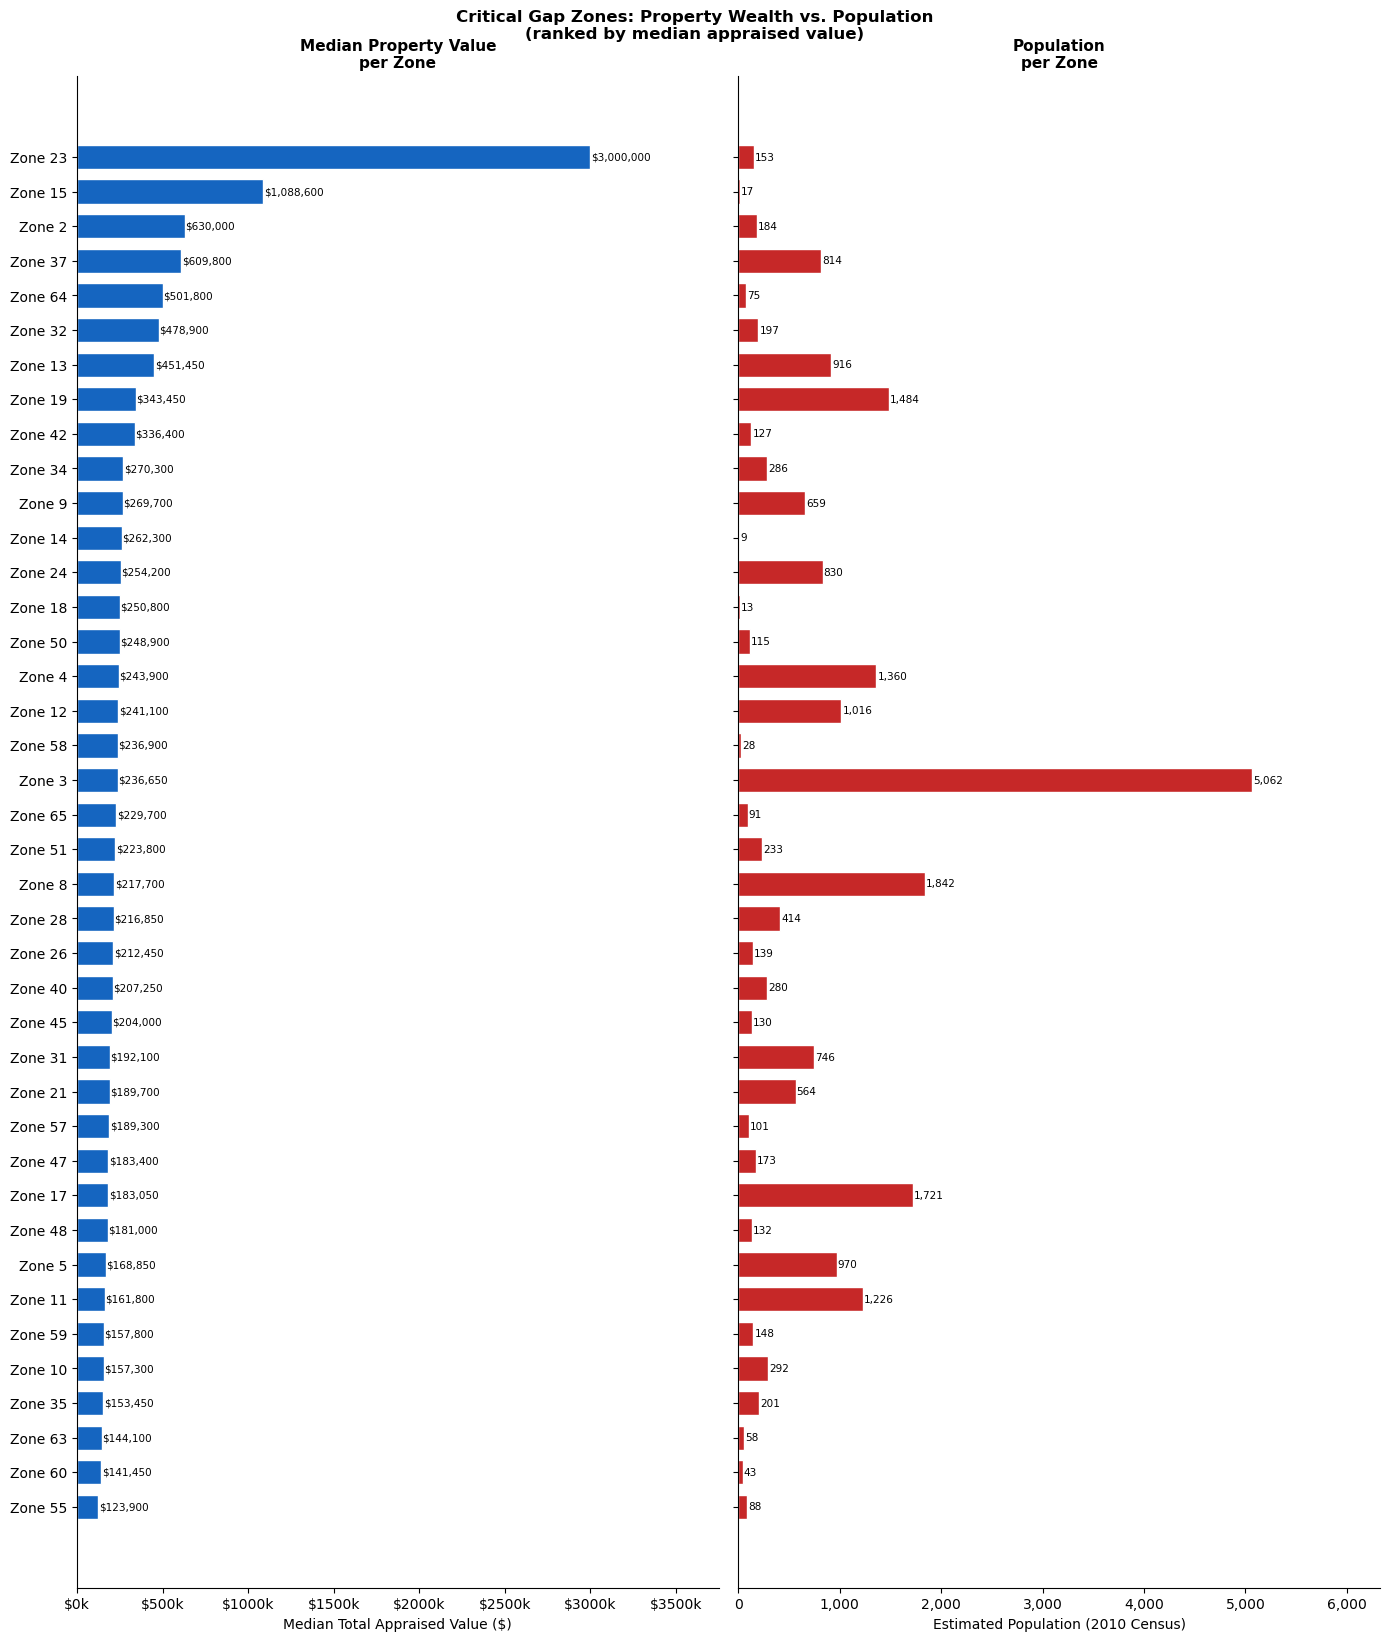

Zone    Parcels    Median Appr      Mean Appr   Population
----------------------------------------------------------
23            5      3,000,000     19,993,220          153
15          965      1,088,600      1,227,486           17
2         3,048        630,000        998,228          184
37           43        609,800      2,412,937          814
64           13        501,800        482,046           75
32          259        478,900        468,793          197
13          508        451,450        507,865          916
19          558        343,450        390,086        1,484
42          133        336,400        638,633          127
34          165        270,300        260,778          286
9           238        269,700        400,046          659
14           22        262,300      8,055,391            9
24          408        254,200        256,936          830
18          741        250,800        309,493           13
50           41        248,900        290,324          1

In [27]:
# ---------------------------
# U) Tax parcel wealth by red zone
# ---------------------------
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Load and reproject tax parcels to WGS84
parcels = gpd.read_file("InvestAtlanta_export/Tax_Parcels_2025.shp")
parcels = parcels[parcels["TOT_APPR"] > 0].copy()
parcels = parcels.to_crs("EPSG:4326")

# Reproject parcels to EPSG:3857 for accurate centroid computation
parcels_3857 = parcels.to_crs("EPSG:3857")

# Spatial join: parcels -> each populated red zone
zone_stats = []
for z in populated:
    # Project poly to 3857 to match parcels
    poly_3857 = gpd.GeoDataFrame(geometry=[z["poly"]], crs="EPSG:4326").to_crs("EPSG:3857").geometry.iloc[0]
    clip = parcels_3857[parcels_3857.geometry.centroid.within(poly_3857)]
    if clip.empty:
        median_val, mean_val, count = 0, 0, 0
    else:
        median_val = clip["TOT_APPR"].median()
        mean_val   = clip["TOT_APPR"].mean()
        count      = len(clip)
    zone_stats.append({**z, "parcel_count": count, "median_appr": median_val, "mean_appr": mean_val})

# Sort by median appraised value
ranked_wealth = sorted(zone_stats, key=lambda z: z["median_appr"], reverse=True)

# --- Side-by-side: median property value vs population ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, len(ranked_wealth) * 0.38 + 1.5))

labels  = [f"Zone {z['zone']}" for z in ranked_wealth]
medians = [z["median_appr"] for z in ranked_wealth]
pops    = [z["population"]   for z in ranked_wealth]

ax1.barh(labels[::-1], medians[::-1], color="#1565c0", edgecolor="white", height=0.7)
for i, val in enumerate(medians[::-1]):
    ax1.text(val + 2000, i, f"${val:,.0f}", va="center", fontsize=7.5)
ax1.set_xlabel("Median Total Appraised Value ($)", fontsize=10)
ax1.set_title("Median Property Value\nper Zone", fontsize=11, fontweight="bold")
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}k"))
ax1.spines[["top", "right"]].set_visible(False)
ax1.set_xlim(0, max(medians) * 1.25)

ax2.barh(labels[::-1], pops[::-1], color="#c62828", edgecolor="white", height=0.7)
for i, pop in enumerate(pops[::-1]):
    ax2.text(pop + 10, i, f"{pop:,}", va="center", fontsize=7.5)
ax2.set_xlabel("Estimated Population (2010 Census)", fontsize=10)
ax2.set_title("Population\nper Zone", fontsize=11, fontweight="bold")
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax2.spines[["top", "right"]].set_visible(False)
ax2.set_xlim(0, max(pops) * 1.25)
ax2.set_yticklabels([])

fig.suptitle("Critical Gap Zones: Property Wealth vs. Population\n(ranked by median appraised value)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("zones_wealth_vs_population.png", dpi=150, bbox_inches="tight")
plt.show()

# Print summary table
header = "{:<6} {:>8} {:>14} {:>14} {:>12}".format("Zone","Parcels","Median Appr","Mean Appr","Population")
print(header)
print("-" * 58)
for z in ranked_wealth:
    print(f"{z['zone']:<6} {z['parcel_count']:>8,} {z['median_appr']:>14,.0f} {z['mean_appr']:>14,.0f} {z['population']:>12,}")


In [28]:
# ---------------------------
# V) Map: red zones colored by median property value (quintiles)
# ---------------------------
import plotly.graph_objects as go
import numpy as np

# Split into 5 quintiles — each gets a clearly distinct color
vals  = np.array([z["median_appr"] for z in ranked_wealth], dtype=float)
edges = np.percentile(vals, [0, 20, 40, 60, 80, 100])

QUINTILE_COLORS = [
    ("#1a237e", "rgba(26,35,126,0.7)"),
    ("#0288d1", "rgba(2,136,209,0.7)"),
    ("#43a047", "rgba(67,160,71,0.7)"),
    ("#fb8c00", "rgba(251,140,0,0.7)"),
    ("#c62828", "rgba(198,40,40,0.7)"),
]
QUINTILE_LABELS = [
    f"Q1 — ${edges[0]:,.0f} to ${edges[1]:,.0f}",
    f"Q2 — ${edges[1]:,.0f} to ${edges[2]:,.0f}",
    f"Q3 — ${edges[2]:,.0f} to ${edges[3]:,.0f}",
    f"Q4 — ${edges[3]:,.0f} to ${edges[4]:,.0f}",
    f"Q5 — ${edges[4]:,.0f} to ${edges[5]:,.0f}",
]

def get_quintile(v):
    for i in range(4):
        if v <= edges[i + 1]:
            return i
    return 4

fig6 = go.Figure()

# Draw polygons
shown = set()
for z, v in zip(ranked_wealth, vals):
    q = get_quintile(v)
    line_color, fill_color = QUINTILE_COLORS[q]
    legend_name = QUINTILE_LABELS[q]
    coords = list(z["poly"].exterior.coords)
    label  = f"Zone {z['zone']} — Q{q+1}<br>Median Value: ${v:,.0f}<br>Population: {z['population']:,}"
    fig6.add_trace(go.Scattermapbox(
        lon=[c[0] for c in coords],
        lat=[c[1] for c in coords],
        mode="lines", fill="toself",
        fillcolor=fill_color,
        line=dict(width=1.5, color=line_color),
        hovertext=label,
        hoverinfo="text",
        name=legend_name,
        showlegend=(q not in shown),
        legendgroup=f"q{q}",
    ))
    shown.add(q)

# Grocery stores
fig6.add_trace(go.Scattermapbox(
    lat=stores_in_atl["latitude"],
    lon=stores_in_atl["longitude"],
    mode="markers",
    marker=dict(size=5, color="#2ecc71"),
    name="Grocery Stores",
))

q_ranges = [f"${edges[i]:,.0f}–${edges[i+1]:,.0f}" for i in range(5)]
print("Quintile ranges:")
for i, r in enumerate(q_ranges):
    print(f"  Q{i+1}: {r}")

fig6.update_layout(
    mapbox=dict(
        style="open-street-map",
        center=dict(lat=np.mean([z["lat"] for z in ranked_wealth]),
                    lon=np.mean([z["lon"] for z in ranked_wealth])),
        zoom=11,
    ),
    margin=dict(l=10, r=10, t=50, b=10),
    title="Critical Gap Zones — Property Value Quintiles (dark blue=cheapest → red=most expensive)",
    legend=dict(orientation="h", y=0.01, x=0.01, bgcolor="rgba(255,255,255,0.8)"),
)

fig6.show()


# Export as standalone interactive HTML
fig6.write_html(
    "atlanta_critical_gaps_map.html",
    include_plotlyjs=True,
    full_html=True,
)
print("Saved: atlanta_critical_gaps_map.html")

Quintile ranges:
  Q1: $123,900–$178,570
  Q2: $178,570–$210,370
  Q3: $210,370–$242,220
  Q4: $242,220–$337,810
  Q5: $337,810–$3,000,000


Saved: atlanta_critical_gaps_map.html
